# Exploratory Data Analysis (EDA)
Airline Passenger Satisfaction Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/airline_passenger_satisfaction.csv')
data_dict = pd.read_csv('../data/data_dictionary.csv')

print("Data Shape:", df.shape)
df.head()

Data Shape: (129880, 24)


,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


## 1. Data Cleaning

In [2]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Handle missing values in 'Arrival Delay' (fill with median)
df['Arrival Delay'].fillna(df['Arrival Delay'].median(), inplace=True)
print("\nMissing values after cleaning:", df['Arrival Delay'].isnull().sum())

Missing Values:
 ID                                          0
Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Service                      0
In-flight Enterta

C:\Users\Tanishk\AppData\Local\Temp\ipykernel_24856\1698145560.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Arrival Delay'].fillna(df['Arrival Delay'].median(), inplace=True)


## 2. Target Variable Distribution

C:\Users\Tanishk\AppData\Local\Temp\ipykernel_24856\1031947339.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Satisfaction', data=df, palette='viridis')


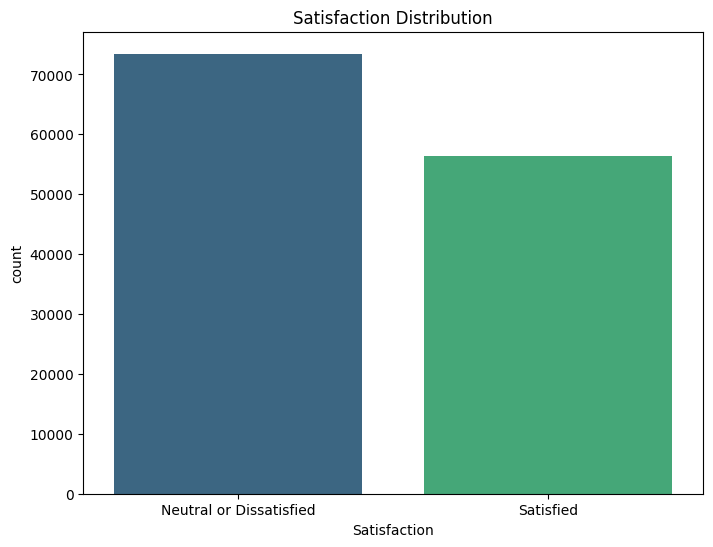

In [3]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Satisfaction', data=df, palette='viridis')
plt.title('Satisfaction Distribution')
plt.show()

## 3. Demographics vs Satisfaction

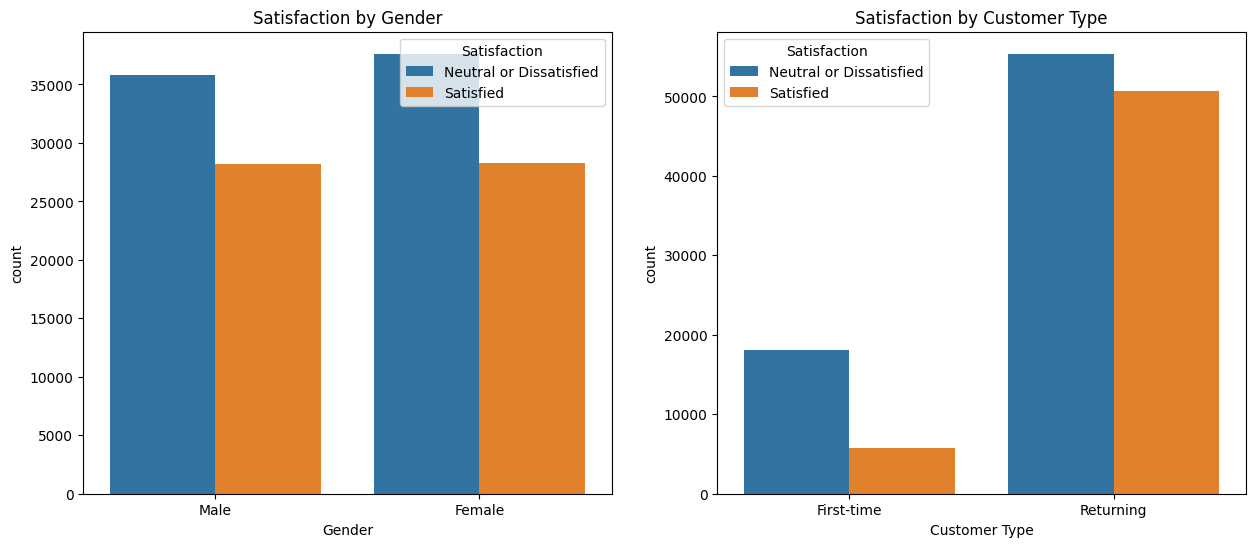

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(x='Gender', hue='Satisfaction', data=df, ax=axes[0])
axes[0].set_title('Satisfaction by Gender')

sns.countplot(x='Customer Type', hue='Satisfaction', data=df, ax=axes[1])
axes[1].set_title('Satisfaction by Customer Type')

plt.show()

## 4. Flight Characteristics

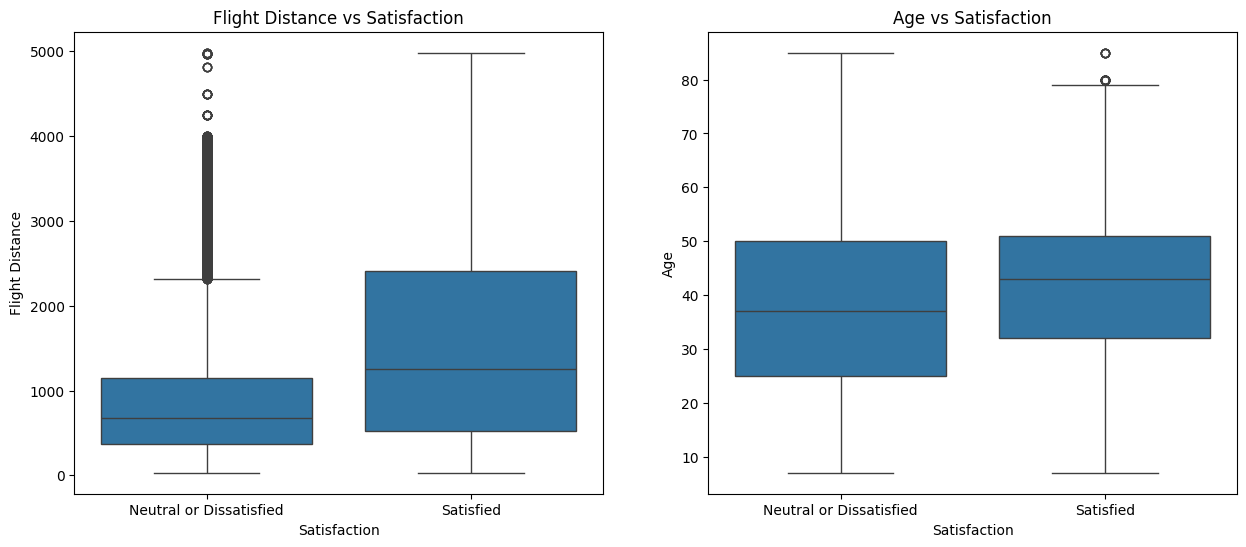

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(x='Satisfaction', y='Flight Distance', data=df, ax=axes[0])
axes[0].set_title('Flight Distance vs Satisfaction')

sns.boxplot(x='Satisfaction', y='Age', data=df, ax=axes[1])
axes[1].set_title('Age vs Satisfaction')

plt.show()

## 5. Delays Analysis

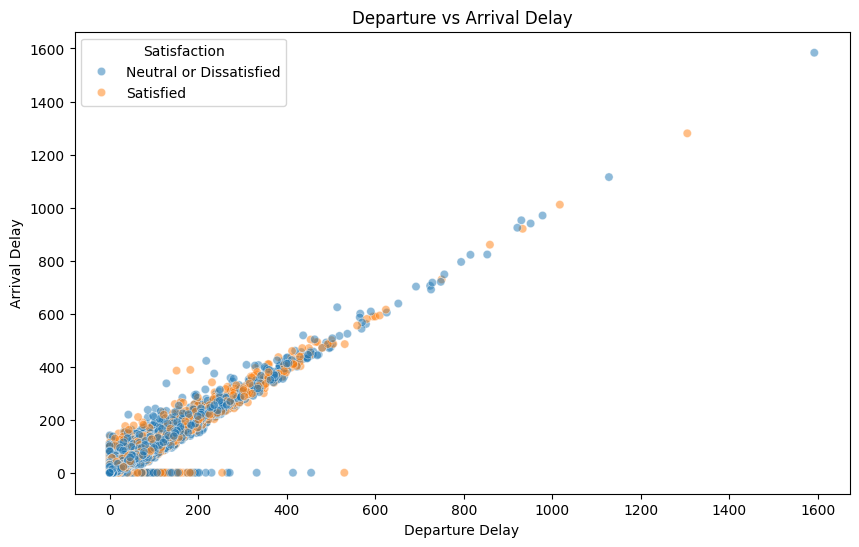

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Departure Delay', y='Arrival Delay', hue='Satisfaction', data=df, alpha=0.5)
plt.title('Departure vs Arrival Delay')
plt.show()

## 6. Service Ratings Heatmap

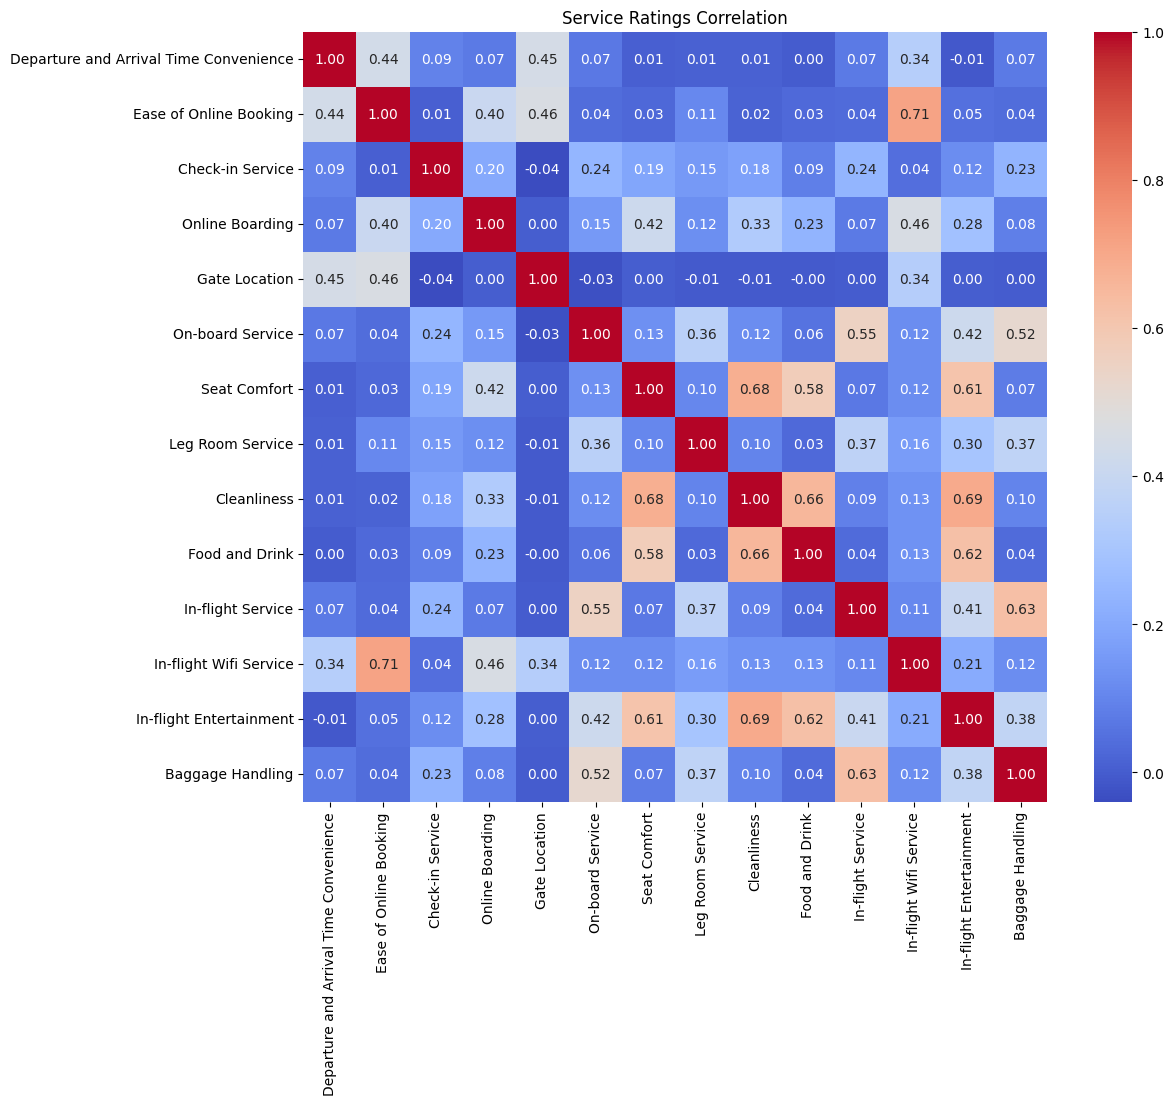

In [7]:
# Extract service columns
service_cols = [
    'Departure and Arrival Time Convenience', 'Ease of Online Booking',
    'Check-in Service', 'Online Boarding', 'Gate Location',
    'On-board Service', 'Seat Comfort', 'Leg Room Service',
    'Cleanliness', 'Food and Drink', 'In-flight Service',
    'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling'
]

# Calculate correlation matrix
corr = df[service_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Service Ratings Correlation')
plt.show()